In [9]:
import tensorflow as tf

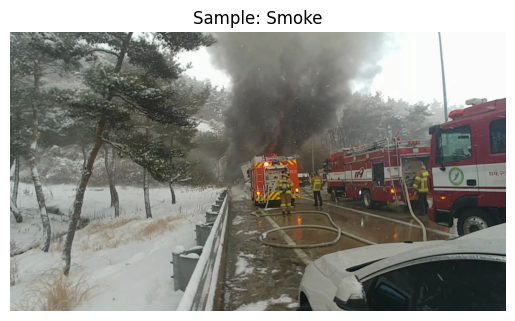

연기 이미지 개수: 315
불 이미지 개수: 264
일반 이미지 개수: 263


In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as img
import os

# 데이터 경로 설정
smoke_dir = 'data/smoke'
fire_dir = 'data/fire'
negative_dir = 'data/negative'

# 임시 출력
smoke_files = os.listdir(smoke_dir)
sample_img_path = os.path.join(smoke_dir, smoke_files[0])
sample_img = img.imread(sample_img_path)

plt.imshow(sample_img)
plt.title("Sample: Smoke")
plt.axis('off')
plt.show()

print(f"연기 이미지 개수: {len(os.listdir(smoke_dir))}")
print(f"불 이미지 개수: {len(os.listdir(fire_dir))}")
print(f"일반 이미지 개수: {len(os.listdir(negative_dir))}")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. 증강 규칙 정의 (훈련용)
train_datagen = ImageDataGenerator(
    rescale=1./255,           
    rotation_range=20,        
    width_shift_range=0.1,    
    height_shift_range=0.1,   
    shear_range=0.1,          
    zoom_range=0.1,           
    horizontal_flip=True,     
    fill_mode='nearest',      
    validation_split=0.2      
)

# 2. 폴더에서 이미지 불러오기
train_generator = train_datagen.flow_from_directory(
    'data',                   
    target_size=(224, 224),  
    batch_size=32,
    class_mode='categorical', # 다중 분류
    subset='training'         
)

val_generator = train_datagen.flow_from_directory(
    'data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'       # 검증용 데이터
)

print(f"클래스 확인: {train_generator.class_indices}")

Found 675 images belonging to 3 classes.
Found 166 images belonging to 3 classes.
클래스 확인: {'fire': 0, 'negative': 1, 'smoke': 2}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import os

# 1. 데이터셋 설정
data_dir = 'data' 
batch_size = 32
img_height = 224
img_width = 224

# 학습 데이터셋 불러오기
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

# 검증 데이터셋 불러오기
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)


# 1. 읽기 에러(손상된 파일)가 나면 무시하고 다음 파일로 넘어감
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
val_ds = val_ds.apply(tf.data.experimental.ignore_errors())

# 2. 데이터를 메모리에 캐싱하여 타임아웃 방지 및 학습 속도 향상
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
# ---------------------------------------------------------

# 2. 모델 설계
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

model = models.Sequential([
    # MobileNetV2 전용 전처리 
    layers.Input(shape=(224, 224, 3)),
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax') # fire, negative, smoke
])

# 3. 컴파일
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# 4. 학습 시작
epochs = 10
print("학습을 시작합니다...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

# 5. 모델 저장
model.save('my_mobilenet_model.keras')
print("모델 저장 완료")

Found 841 files belonging to 3 classes.
Using 673 files for training.
Found 841 files belonging to 3 classes.
Using 168 files for validation.
Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
학습을 시작합니다...
Epoch 1/10
      6/Unknown 73s 11s/step - accuracy: 0.4254 - loss: 1.2776

2026-02-26 09:04:29.297991: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 638/1080


     20/Unknown 226s 11s/step - accuracy: 0.5541 - loss: 1.0256

2026-02-26 09:07:01.874818: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/iseung-eun/Desktop/e-gleEye/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


21/21 ━━━━━━━━━━━━━━━━━━━━ 295s 14s/step - accuracy: 0.6459 - loss: 0.8419 - val_accuracy: 0.8333 - val_loss: 0.4217
Epoch 2/10


...

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 295ms/step - accuracy: 0.8674 - loss: 0.3616 - val_accuracy: 0.8929 - val_loss: 0.2609
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 293ms/step - accuracy: 0.8799 - loss: 0.3055 - val_accuracy: 0.9048 - val_loss: 0.2427
Epoch 5/10


2026-02-26 09:08:28.794065: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - accuracy: 0.8861 - loss: 0.2901 - val_accuracy: 0.9048 - val_loss: 0.2394
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 260ms/step - accuracy: 0.9142 - loss: 0.2326 - val_accuracy: 0.9226 - val_loss: 0.2063
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step - accuracy: 0.9189 - loss: 0.2164 - val_accuracy: 0.9405 - val_loss: 0.1825
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 278ms/step - accuracy: 0.9345 - loss: 0.1775 - val_accuracy: 0.9167 - val_loss: 0.2004
Epoch 9/10


2026-02-26 09:08:50.885119: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 267ms/step - accuracy: 0.9298 - loss: 0.1709 - val_accuracy: 0.9405 - val_loss: 0.1418
Epoch 10/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 274ms/step - accuracy: 0.9470 - loss: 0.1648 - val_accuracy: 0.9464 - val_loss: 0.1392
모델 저장 완료


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# 1. 데이터셋 설정 (이전과 동일)
data_dir = 'data' 
batch_size = 32
img_height = 224
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123,
    image_size=(img_height, img_width), batch_size=batch_size, label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=(img_height, img_width), batch_size=batch_size, label_mode='categorical'
)

# 에러 방지 및 최적화
train_ds = train_ds.apply(tf.data.experimental.ignore_errors()).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.apply(tf.data.experimental.ignore_errors()).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# 2. ResNet50 모델 설계
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    # ResNet50 전용 전처리
    layers.Lambda(preprocess_input, name='resnet_preprocess'),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'), # ResNet의 깊이에 맞춰 노드 확장
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

# 3. 컴파일
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. 학습 시작
print("ResNet50으로 학습을 시작합니다...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

# 5. 모델 저장
model.save('my_resnet_model.keras')
print("ResNet 모델 저장 완료")

Found 841 files belonging to 3 classes.
Using 673 files for training.
Found 841 files belonging to 3 classes.
Using 168 files for validation.
ResNet50으로 학습을 시작합니다...
Epoch 1/10
      6/Unknown 47s 7s/step - accuracy: 0.3748 - loss: 1.8257

2026-02-26 09:31:02.809947: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 638/1080


     21/Unknown 95s 4s/step - accuracy: 0.5381 - loss: 1.2732

/Users/iseung-eun/Desktop/e-gleEye/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


21/21 ━━━━━━━━━━━━━━━━━━━━ 189s 9s/step - accuracy: 0.6474 - loss: 0.9286 - val_accuracy: 0.8988 - val_loss: 0.2757
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 971ms/step - accuracy: 0.8487 - loss: 0.3795 - val_accuracy: 0.9405 - val_loss: 0.2234
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 990ms/step - accuracy: 0.9064 - loss: 0.2564 - val_accuracy: 0.9405 - val_loss: 0.1984
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 946ms/step - accuracy: 0.8783 - loss: 0.2851 - val_accuracy: 0.9345 - val_loss: 0.1858
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 952ms/step - accuracy: 0.8955 - loss: 0.2511 - val_accuracy: 0.9464 - val_loss: 0.1650
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 954ms/step - accuracy: 0.9282 - loss: 0.1881 - val_accuracy: 0.9464 - val_loss: 0.1593
Epoch 7/10


2026-02-26 09:35:02.031080: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9360 - loss: 0.1614 - val_accuracy: 0.9464 - val_loss: 0.1304
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9516 - loss: 0.1477 - val_accuracy: 0.9345 - val_loss: 0.1260
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 970ms/step - accuracy: 0.9501 - loss: 0.1255 - val_accuracy: 0.9226 - val_loss: 0.1791
Epoch 10/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 966ms/step - accuracy: 0.9438 - loss: 0.1431 - val_accuracy: 0.9524 - val_loss: 0.1178
ResNet 모델 저장 완료


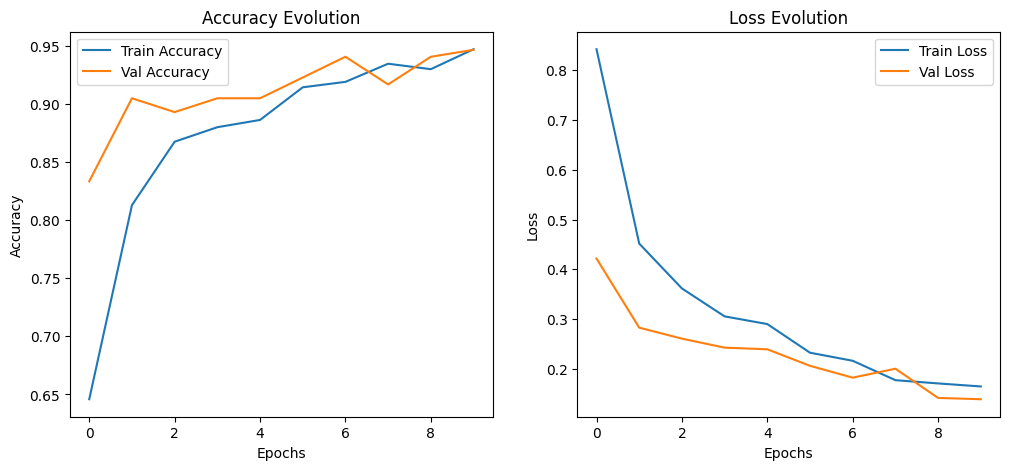

In [6]:
import matplotlib.pyplot as plt

# 정확도 그래프
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


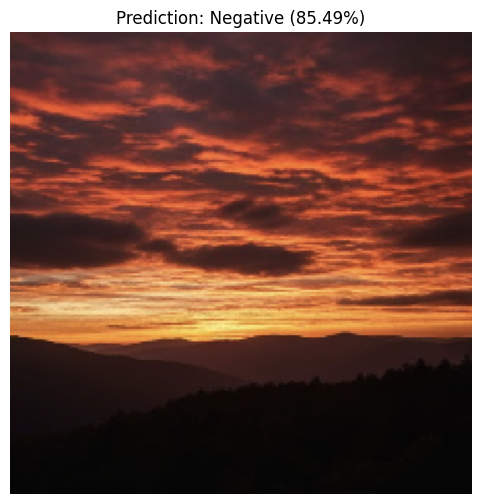

분석 결과: 이 이미지는 'Negative'일 확률이 85.49%입니다.


In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1. 모델 로드
model = tf.keras.models.load_model(
    'my_mobilenet_model.keras',
    custom_objects={'preprocess_input': preprocess_input}
)

def predict_fire_image(img_path):
    # 이미지 불러오기 및 전처리
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # 배치 차원 추가
    
    # 모델 예측 
    predictions = model.predict(img_array)
    
    # 클래스 정의
    class_names = ['Fire', 'Negative', 'Smoke']
    
    # 결과 계산
    result_idx = np.argmax(predictions[0])
    result_label = class_names[result_idx]
    confidence = predictions[0][result_idx] * 100

    # 시각화
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Prediction: {result_label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
    
    print(f"분석 결과: 이 이미지는 '{result_label}'일 확률이 {confidence:.2f}%입니다.")

# 2. 테스트 실행
predict_fire_image('data/노을.jpg')